In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


In [2]:
coords = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/coords_mouse.csv',index_col=0)
meta = pd.read_csv('/mnt/morbo/Data/Users/kwoyshner/cerebellum/data/mouse_CB_meta.csv',index_col=0)


## SPATIAL DATA

In [ ]:
tricycle_pos = pd.read_csv('tricyclePosition.csv',index_col=0)
meta_folia = meta[meta['folia'] == 'folia']
tricycle_pos_folia = tricycle_pos.loc[meta_folia.index]

/tmp/ipykernel_847775/1752351985.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[r,c].set_title(meta[meta.index.str.contains(im)]['treatment'][0])
/tmp/ipykernel_847775/1752351985.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[r,c].set_title(meta[meta.index.str.contains(im)]['treatment'][0])
/tmp/ipykernel_847775/1752351985.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[r,c].set_title(meta[meta.index.

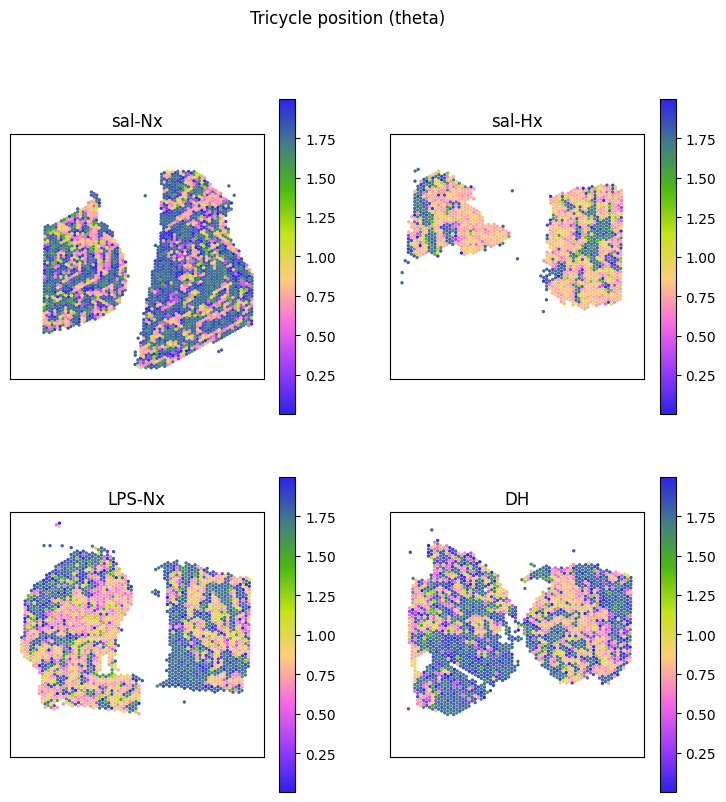

In [ ]:
#images = list(np.unique([x.split('_')[0] for x in tricycle_pos.index]))
RugPalette_v = ["#2E22EA", "#9E3DFB", "#F86BE2", "#FCCE7B", "#C4E416", "#4BBA0F", "#447D87", "#2C24E9"]
rug_cmap = LinearSegmentedColormap.from_list("RugPalette", RugPalette_v)
tricycle_pos['tricyclePosition_theta'] = tricycle_pos['tricyclePosition']/np.pi


images = ['C', 'MH', 'L', 'DH']

fig,axes = plt.subplots(2,2,figsize=(9,9),sharex=True,sharey=True)
fig.suptitle('Tricycle position (theta)')
i = 0
for r in range(axes.shape[0]):
    for c in range(axes.shape[1]):
        im = images[i] + '_'
        patterns_im = tricycle_pos[tricycle_pos.index.str.contains(im)]
        axes[r,c].set(aspect='equal')
        #scat_background = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=1, alpha=0.1,c='gray')
        scat = axes[r,c].scatter(coords.loc[patterns_im.index,'imagerow'],coords.loc[patterns_im.index,'imagecol'], s=2, c=patterns_im['tricyclePosition_theta'],alpha=1,cmap=rug_cmap)

        axes[r,c].set_yticklabels([])
        axes[r,c].set_xticklabels([])
        axes[r,c].set_xticks([])
        axes[r,c].set_yticks([])

        axes[r,c].set_title(meta[meta.index.str.contains(im)]['treatment'][0])
        fig.colorbar(scat, ax=axes[r,c])

        i+=1
plt.savefig('tricyclePosition_mouse_colorAdjusted.pdf')
